# FrontierMem — Kaggle Experiments and Model Comparison

Clean, reproducible notebook for the final prototype snapshot. It preserves the executed 1.5B and 3B runs while removing duplicated/debug cells from the raw experiment log.

In [7]:
import os
import shutil

SOURCE_DIR = (
    "/kaggle/input/datasets/mohammadamanlou/"
    "frontier/frontiermem_llm_prototype_fixed"
)

WORK_DIR = "/kaggle/working/frontiermem_llm_prototype_fixed"

if os.path.exists(WORK_DIR):
    shutil.rmtree(WORK_DIR)

shutil.copytree(SOURCE_DIR, WORK_DIR)

print("Copied successfully.")
print("Source exists:", os.path.exists(SOURCE_DIR))
print("Work directory exists:", os.path.exists(WORK_DIR))

Copied successfully.
Source exists: True
Work directory exists: True


In [9]:
%cd /kaggle/working/frontiermem_llm_prototype_fixed

/kaggle/working/frontiermem_llm_prototype_fixed


In [10]:
!pwd
!find . -maxdepth 2 -type f | sort | head -60

/kaggle/working/frontiermem_llm_prototype_fixed
./data/frontier_suite_mini.csv
./frontiermem/baselines.py
./frontiermem/data.py
./frontiermem/evaluation.py
./frontiermem/hf_small_llm.py
./frontiermem/__init__.py
./frontiermem/memory.py
./frontiermem/tiny_lm.py
./frontiermem/visualization.py
./MANIFEST.txt
./notebooks/FrontierMem_Small_LLM_Prototype.ipynb
./pyproject.toml
./README.md
./requirements-hf.txt
./requirements.txt
./results/boundary_metrics_all_local.png
./results/boundary_metrics_rules.png
./results/boundary_metrics_tiny_lm.png
./results/error_rates_all_local.png
./results/error_rates_rules.png
./results/error_rates_tiny_lm.png
./results/example_rule_memories.json
./results/main_metrics_all_local.png
./results/main_metrics_rules.png
./results/main_metrics_tiny_lm.png
./results/metrics_all_local.csv
./results/metrics_rules_and_baselines.csv
./results/metrics_tiny_lm.csv
./results/rule_memory_extraction_metrics.csv
./RESULTS_SUMMARY.md
./results/test_predictions_rules_and_basel

In [11]:
!pip install -q -U \
    "transformers>=4.45,<5" \
    accelerate \
    safetensors \
    sentencepiece \
    huggingface_hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 86.3 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 19.3 MB/s eta 0:00:00


In [12]:
import transformers
import accelerate
import torch

print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)
print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

Transformers: 4.57.6
Accelerate: 1.14.0
Torch: 2.10.0+cu128
CUDA: True


## 1. Smoke test

In [13]:
!python run_qwen_fast_ablation.py \
    --model Qwen/Qwen2.5-1.5B-Instruct \
    --mode gold_memory_llm \
    --max-examples 2

tokenizer_config.json: 7.30kB [00:00, 22.3MB/s]
vocab.json: 2.78MB [00:00, 45.7MB/s]
merges.txt: 1.67MB [00:00, 120MB/s]
tokenizer.json: 7.03MB [00:00, 156MB/s]
config.json: 100%|█████████████████████████████| 660/660 [00:00<00:00, 5.66MB/s]
model.safetensors: 100%|███████████████████| 3.09G/3.09G [00:32<00:00, 95.9MB/s]
generation_config.json: 100%|██████████████████| 242/242 [00:00<00:00, 1.40MB/s]
[1/2] mode=gold_memory_llm family=writing_directness gold=APPLY
[2/2] mode=gold_memory_llm family=food_vegetarian gold=APPLY
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(

Metrics
                                 model  accuracy  balanced_accuracy  macro_f1  inside_accuracy  outside_accuracy  near_accuracy  overgeneralization_rate  unnecessary_clarification_rate  twin_exact

## 2. Qwen2.5-1.5B ablation runs

In [14]:
!python run_qwen_fast_ablation.py \
    --model Qwen/Qwen2.5-1.5B-Instruct \
    --mode gold_memory_llm \
    --max-examples 72

[1/72] mode=gold_memory_llm family=writing_directness gold=APPLY
[2/72] mode=gold_memory_llm family=food_vegetarian gold=APPLY
[3/72] mode=gold_memory_llm family=food_quick_meals gold=CLARIFY
[4/72] mode=gold_memory_llm family=education_answer_only gold=APPLY
[5/72] mode=gold_memory_llm family=writing_formality gold=APPLY
[6/72] mode=gold_memory_llm family=education_detail gold=APPLY
[7/72] mode=gold_memory_llm family=education_detail gold=IGNORE
[8/72] mode=gold_memory_llm family=education_examples gold=IGNORE
[9/72] mode=gold_memory_llm family=travel_budget gold=APPLY
[10/72] mode=gold_memory_llm family=food_spiciness gold=APPLY
[11/72] mode=gold_memory_llm family=food_vegetarian gold=IGNORE
[12/72] mode=gold_memory_llm family=travel_budget gold=APPLY
[13/72] mode=gold_memory_llm family=food_spiciness gold=APPLY
[14/72] mode=gold_memory_llm family=writing_formality gold=APPLY
[15/72] mode=gold_memory_llm family=education_examples gold=APPLY
[16/72] mode=gold_memory_llm family=travel_

In [15]:
!python run_qwen_fast_ablation.py \
    --model Qwen/Qwen2.5-1.5B-Instruct \
    --mode rule_memory_llm \
    --max-examples 72

[1/72] mode=rule_memory_llm family=writing_directness gold=APPLY
[2/72] mode=rule_memory_llm family=food_vegetarian gold=APPLY
[3/72] mode=rule_memory_llm family=food_quick_meals gold=CLARIFY
[4/72] mode=rule_memory_llm family=education_answer_only gold=APPLY
[5/72] mode=rule_memory_llm family=writing_formality gold=APPLY
[6/72] mode=rule_memory_llm family=education_detail gold=APPLY
[7/72] mode=rule_memory_llm family=education_detail gold=IGNORE
[8/72] mode=rule_memory_llm family=education_examples gold=IGNORE
[9/72] mode=rule_memory_llm family=travel_budget gold=APPLY
[10/72] mode=rule_memory_llm family=food_spiciness gold=APPLY
[11/72] mode=rule_memory_llm family=food_vegetarian gold=IGNORE
[12/72] mode=rule_memory_llm family=travel_budget gold=APPLY
[13/72] mode=rule_memory_llm family=food_spiciness gold=APPLY
[14/72] mode=rule_memory_llm family=writing_formality gold=APPLY
[15/72] mode=rule_memory_llm family=education_examples gold=APPLY
[16/72] mode=rule_memory_llm family=travel_

In [16]:
!python run_qwen_fast_ablation.py \
    --model Qwen/Qwen2.5-1.5B-Instruct \
    --mode llm_memory_rule \
    --max-examples 72

[1/72] mode=llm_memory_rule family=writing_directness gold=APPLY
[2/72] mode=llm_memory_rule family=food_vegetarian gold=APPLY
[3/72] mode=llm_memory_rule family=food_quick_meals gold=CLARIFY
[4/72] mode=llm_memory_rule family=education_answer_only gold=APPLY
[5/72] mode=llm_memory_rule family=writing_formality gold=APPLY
[6/72] mode=llm_memory_rule family=education_detail gold=APPLY
[7/72] mode=llm_memory_rule family=education_detail gold=IGNORE
[8/72] mode=llm_memory_rule family=education_examples gold=IGNORE
[9/72] mode=llm_memory_rule family=travel_budget gold=APPLY
[10/72] mode=llm_memory_rule family=food_spiciness gold=APPLY
[11/72] mode=llm_memory_rule family=food_vegetarian gold=IGNORE
[12/72] mode=llm_memory_rule family=travel_budget gold=APPLY
[13/72] mode=llm_memory_rule family=food_spiciness gold=APPLY
[14/72] mode=llm_memory_rule family=writing_formality gold=APPLY
[15/72] mode=llm_memory_rule family=education_examples gold=APPLY
[16/72] mode=llm_memory_rule family=travel_

In [25]:
!python run_qwen_fast_ablation.py \
    --model Qwen/Qwen2.5-1.5B-Instruct \
    --mode full_llm \
    --max-examples 72

[1/72] mode=full_llm family=writing_directness gold=APPLY
[2/72] mode=full_llm family=food_vegetarian gold=APPLY
[3/72] mode=full_llm family=food_quick_meals gold=CLARIFY
[4/72] mode=full_llm family=education_answer_only gold=APPLY
[5/72] mode=full_llm family=writing_formality gold=APPLY
[6/72] mode=full_llm family=education_detail gold=APPLY
[7/72] mode=full_llm family=education_detail gold=IGNORE
[8/72] mode=full_llm family=education_examples gold=IGNORE
[9/72] mode=full_llm family=travel_budget gold=APPLY
[10/72] mode=full_llm family=food_spiciness gold=APPLY
[11/72] mode=full_llm family=food_vegetarian gold=IGNORE
[12/72] mode=full_llm family=travel_budget gold=APPLY
[13/72] mode=full_llm family=food_spiciness gold=APPLY
[14/72] mode=full_llm family=writing_formality gold=APPLY
[15/72] mode=full_llm family=education_examples gold=APPLY
[16/72] mode=full_llm family=travel_proximity gold=APPLY
[17/72] mode=full_llm family=food_quick_meals gold=APPLY
[18/72] mode=full_llm family=food_

## 3. Qwen2.5-1.5B analysis

In [26]:
from pathlib import Path
import os
import pandas as pd
from IPython.display import display

PROJECT_DIR = Path(
    "/kaggle/working/frontiermem_llm_prototype_fixed"
)
RESULTS_DIR = PROJECT_DIR / "results"

MODEL_SLUG = "Qwen2_5-1_5B-Instruct"

MODES = [
    "gold_memory_llm",
    "rule_memory_llm",
    "llm_memory_rule",
    "full_llm",
]

print("Project exists:", PROJECT_DIR.exists())
print("Results exists:", RESULTS_DIR.exists())

for path in sorted(RESULTS_DIR.glob("*Qwen2_5-1_5B-Instruct*")):
    print(
        path.name,
        "-",
        round(path.stat().st_size / 1024, 2),
        "KB",
    )

Project exists: True
Results exists: True
extraction_Qwen2_5-1_5B-Instruct_full_llm.csv - 0.17 KB
extraction_Qwen2_5-1_5B-Instruct_llm_memory_rule.csv - 0.17 KB
metrics_Qwen2_5-1_5B-Instruct_full_llm.csv - 0.34 KB
metrics_Qwen2_5-1_5B-Instruct_gold_memory_llm.csv - 0.41 KB
metrics_Qwen2_5-1_5B-Instruct_llm_memory_rule.csv - 0.42 KB
metrics_Qwen2_5-1_5B-Instruct_rule_memory_llm.csv - 0.39 KB
predictions_Qwen2_5-1_5B-Instruct_full_llm.csv - 189.1 KB
predictions_Qwen2_5-1_5B-Instruct_gold_memory_llm.csv - 133.19 KB
predictions_Qwen2_5-1_5B-Instruct_llm_memory_rule.csv - 168.65 KB
predictions_Qwen2_5-1_5B-Instruct_rule_memory_llm.csv - 133.37 KB


In [27]:
missing = []

for mode in MODES:
    pred_path = (
        RESULTS_DIR
        / f"predictions_{MODEL_SLUG}_{mode}.csv"
    )
    metric_path = (
        RESULTS_DIR
        / f"metrics_{MODEL_SLUG}_{mode}.csv"
    )

    if not pred_path.exists():
        missing.append(str(pred_path.name))

    if not metric_path.exists():
        missing.append(str(metric_path.name))

if missing:
    print("Missing files:")
    for name in missing:
        print("-", name)
else:
    print("All four experiments are available.")

All four experiments are available.


In [30]:
metric_frames = []

for mode in MODES:
    path = RESULTS_DIR / f"metrics_{MODEL_SLUG}_{mode}.csv"

    if path.exists():
        part = pd.read_csv(path)
        part.insert(0, "mode", mode)
        metric_frames.append(part)

all_metrics = pd.concat(
    metric_frames,
    ignore_index=True,
)

main_columns = [
    "mode",
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "inside_accuracy",
    "outside_accuracy",
    "near_accuracy",
    "overgeneralization_rate",
    "unnecessary_clarification_rate",
    "twin_exact_match",
    "twin_discrimination_accuracy",
    "n_examples",
]

main_columns = [
    col for col in main_columns
    if col in all_metrics.columns
]

metrics_summary = all_metrics[main_columns].copy()

display(
    metrics_summary
    .sort_values("accuracy", ascending=False)
    .reset_index(drop=True)
)

,mode,accuracy,balanced_accuracy,macro_f1,inside_accuracy,outside_accuracy,near_accuracy,overgeneralization_rate,unnecessary_clarification_rate,twin_exact_match,twin_discrimination_accuracy,n_examples
0,rule_memory_llm,0.708333,0.708333,0.684453,1.000000,0.333333,0.791667,0.541667,0.062500,1.000000,1.000000,72
1,llm_memory_rule,0.666667,0.666667,0.653465,0.833333,0.375000,0.791667,0.125000,0.333333,0.333333,0.666667,72
2,gold_memory_llm,0.625000,0.625000,0.600402,1.000000,0.291667,0.583333,0.583333,0.062500,0.666667,0.666667,72
3,full_llm,0.333333,0.333333,0.166667,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,72


In [31]:
percentage_columns = [
    col for col in metrics_summary.columns
    if col not in ["mode", "n_examples"]
]

metrics_percentage = metrics_summary.copy()

for col in percentage_columns:
    metrics_percentage[col] = (
        metrics_percentage[col] * 100
    ).round(2)

display(
    metrics_percentage
    .sort_values("accuracy", ascending=False)
    .reset_index(drop=True)
)

,mode,accuracy,balanced_accuracy,macro_f1,inside_accuracy,outside_accuracy,near_accuracy,overgeneralization_rate,unnecessary_clarification_rate,twin_exact_match,twin_discrimination_accuracy,n_examples
0,rule_memory_llm,70.83,70.83,68.45,100.00,33.33,79.17,54.17,6.25,100.00,100.00,72
1,llm_memory_rule,66.67,66.67,65.35,83.33,37.50,79.17,12.50,33.33,33.33,66.67,72
2,gold_memory_llm,62.50,62.50,60.04,100.00,29.17,58.33,58.33,6.25,66.67,66.67,72
3,full_llm,33.33,33.33,16.67,0.00,100.00,0.00,0.00,0.00,0.00,0.00,72


In [32]:
summary_path = (
    RESULTS_DIR
    / "qwen_1_5b_ablation_summary.csv"
)

metrics_summary.to_csv(
    summary_path,
    index=False,
)

print("Saved:", summary_path)

Saved: /kaggle/working/frontiermem_llm_prototype_fixed/results/qwen_1_5b_ablation_summary.csv


In [33]:
LABELS = ["APPLY", "IGNORE", "CLARIFY"]

distribution_rows = []

for mode in MODES:
    path = (
        RESULTS_DIR
        / f"predictions_{MODEL_SLUG}_{mode}.csv"
    )

    if not path.exists():
        continue

    df = pd.read_csv(path)

    print("\n" + "=" * 80)
    print("Mode:", mode)

    print("\nGold distribution:")
    print(df["action"].value_counts().to_dict())

    print("\nPrediction distribution:")
    print(df["prediction"].value_counts().to_dict())

    for label in LABELS:
        distribution_rows.append({
            "mode": mode,
            "label": label,
            "gold_count": int(
                (df["action"] == label).sum()
            ),
            "prediction_count": int(
                (df["prediction"] == label).sum()
            ),
        })

distribution_df = pd.DataFrame(distribution_rows)

display(distribution_df)


Mode: gold_memory_llm

Gold distribution:
{'APPLY': 24, 'CLARIFY': 24, 'IGNORE': 24}

Prediction distribution:
{'APPLY': 48, 'CLARIFY': 17, 'IGNORE': 7}

Mode: rule_memory_llm

Gold distribution:
{'APPLY': 24, 'CLARIFY': 24, 'IGNORE': 24}

Prediction distribution:
{'APPLY': 42, 'CLARIFY': 22, 'IGNORE': 8}

Mode: llm_memory_rule

Gold distribution:
{'APPLY': 24, 'CLARIFY': 24, 'IGNORE': 24}

Prediction distribution:
{'CLARIFY': 35, 'APPLY': 25, 'IGNORE': 12}

Mode: full_llm

Gold distribution:
{'APPLY': 24, 'CLARIFY': 24, 'IGNORE': 24}

Prediction distribution:
{'IGNORE': 72}


,mode,label,gold_count,prediction_count
0,gold_memory_llm,APPLY,24,48
1,gold_memory_llm,IGNORE,24,7
2,gold_memory_llm,CLARIFY,24,17
3,rule_memory_llm,APPLY,24,42
4,rule_memory_llm,IGNORE,24,8
5,rule_memory_llm,CLARIFY,24,22
6,llm_memory_rule,APPLY,24,25
7,llm_memory_rule,IGNORE,24,12
8,llm_memory_rule,CLARIFY,24,35
9,full_llm,APPLY,24,0


In [34]:
distribution_df.to_csv(
    RESULTS_DIR
    / "qwen_1_5b_prediction_distribution.csv",
    index=False,
)

In [35]:
confusion_matrices = {}

for mode in MODES:
    path = (
        RESULTS_DIR
        / f"predictions_{MODEL_SLUG}_{mode}.csv"
    )

    if not path.exists():
        continue

    df = pd.read_csv(path)

    cm = pd.crosstab(
        df["action"],
        df["prediction"],
        rownames=["Gold"],
        colnames=["Prediction"],
    )

    cm = cm.reindex(
        index=LABELS,
        columns=LABELS,
        fill_value=0,
    )

    confusion_matrices[mode] = cm

    print("\n" + "=" * 80)
    print("Confusion Matrix:", mode)
    display(cm)

    cm.to_csv(
        RESULTS_DIR
        / f"confusion_{MODEL_SLUG}_{mode}.csv"
    )


Confusion Matrix: gold_memory_llm


Prediction,APPLY,IGNORE,CLARIFY
Gold,,,
APPLY,24,0,0
IGNORE,14,7,3
CLARIFY,10,0,14



Confusion Matrix: rule_memory_llm


Prediction,APPLY,IGNORE,CLARIFY
Gold,,,
APPLY,24,0,0
IGNORE,13,8,3
CLARIFY,5,0,19



Confusion Matrix: llm_memory_rule


Prediction,APPLY,IGNORE,CLARIFY
Gold,,,
APPLY,20,0,4
IGNORE,3,9,12
CLARIFY,2,3,19



Confusion Matrix: full_llm


Prediction,APPLY,IGNORE,CLARIFY
Gold,,,
APPLY,0,24,0
IGNORE,0,24,0
CLARIFY,0,24,0


In [36]:
extraction_frames = []

for mode in ["llm_memory_rule", "full_llm"]:
    path = (
        RESULTS_DIR
        / f"extraction_{MODEL_SLUG}_{mode}.csv"
    )

    if path.exists():
        part = pd.read_csv(path)
        part["mode"] = mode
        extraction_frames.append(part)

if extraction_frames:
    extraction_all = pd.concat(
        extraction_frames,
        ignore_index=True,
    )

    extraction_pivot = extraction_all.pivot(
        index="metric",
        columns="mode",
        values="score",
    )

    display(extraction_pivot)

    extraction_pivot.to_csv(
        RESULTS_DIR
        / "qwen_1_5b_extraction_summary.csv"
    )
else:
    print("No extraction files were found.")

mode,full_llm,llm_memory_rule
metric,,
family_correct,0.375000,0.375000
information_type_correct,0.111111,0.111111
owner_correct,0.000000,0.000000
profile_variant_correct,0.902778,0.902778
temporal_correct,0.847222,0.847222


In [37]:
display(
    (extraction_pivot * 100).round(2)
)

mode,full_llm,llm_memory_rule
metric,,
family_correct,37.50,37.50
information_type_correct,11.11,11.11
owner_correct,0.00,0.00
profile_variant_correct,90.28,90.28
temporal_correct,84.72,84.72


In [38]:
parser_rows = []

for mode in MODES:
    path = (
        RESULTS_DIR
        / f"predictions_{MODEL_SLUG}_{mode}.csv"
    )

    if not path.exists():
        continue

    df = pd.read_csv(path)

    for column in [
        "memory_parse_mode",
        "decision_parse_mode",
    ]:
        if column not in df.columns:
            continue

        counts = (
            df[column]
            .fillna("missing")
            .astype(str)
            .value_counts()
        )

        for parse_mode, count in counts.items():
            parser_rows.append({
                "experiment": mode,
                "parser_stage": column,
                "parse_mode": parse_mode,
                "count": int(count),
            })

parser_summary = pd.DataFrame(parser_rows)

display(parser_summary)

,experiment,parser_stage,parse_mode,count
0,gold_memory_llm,memory_parse_mode,gold,72
1,gold_memory_llm,decision_parse_mode,llm_label,72
2,rule_memory_llm,memory_parse_mode,rule,72
3,rule_memory_llm,decision_parse_mode,llm_label,72
4,llm_memory_rule,memory_parse_mode,json,72
5,llm_memory_rule,decision_parse_mode,rule_policy,72
6,full_llm,memory_parse_mode,json,72
7,full_llm,decision_parse_mode,json,72


In [39]:
parser_summary.to_csv(
    RESULTS_DIR
    / "qwen_1_5b_parser_summary.csv",
    index=False,
)

In [40]:
fallback_rows = []

for mode in MODES:
    path = (
        RESULTS_DIR
        / f"predictions_{MODEL_SLUG}_{mode}.csv"
    )

    if not path.exists():
        continue

    df = pd.read_csv(path)

    for column in [
        "memory_parse_mode",
        "decision_parse_mode",
    ]:
        if column not in df.columns:
            continue

        fallback_count = (
            df[column]
            .fillna("")
            .astype(str)
            .str.contains(
                "fallback",
                case=False,
                regex=False,
            )
            .sum()
        )

        fallback_rows.append({
            "mode": mode,
            "stage": column,
            "fallback_count": int(fallback_count),
            "total": len(df),
        })

fallback_summary = pd.DataFrame(fallback_rows)

display(fallback_summary)

,mode,stage,fallback_count,total
0,gold_memory_llm,memory_parse_mode,0,72
1,gold_memory_llm,decision_parse_mode,0,72
2,rule_memory_llm,memory_parse_mode,0,72
3,rule_memory_llm,decision_parse_mode,0,72
4,llm_memory_rule,memory_parse_mode,0,72
5,llm_memory_rule,decision_parse_mode,0,72
6,full_llm,memory_parse_mode,0,72
7,full_llm,decision_parse_mode,0,72


## 4. Full-pipeline error analysis

In [41]:
full_path = (
    RESULTS_DIR
    / f"predictions_{MODEL_SLUG}_full_llm.csv"
)

full_df = pd.read_csv(full_path)

full_df["correct"] = (
    full_df["action"] == full_df["prediction"]
)

print("Examples:", len(full_df))
print("Correct:", int(full_df["correct"].sum()))
print("Incorrect:", int((~full_df["correct"]).sum()))
print("Accuracy:", round(full_df["correct"].mean(), 4))

Examples: 72
Correct: 24
Incorrect: 48
Accuracy: 0.3333


In [42]:
zone_analysis = (
    full_df
    .groupby("zone", dropna=False)
    .agg(
        n=("correct", "size"),
        correct=("correct", "sum"),
        accuracy=("correct", "mean"),
    )
    .reset_index()
)

display(zone_analysis)

zone_analysis.to_csv(
    RESULTS_DIR / "full_llm_by_zone.csv",
    index=False,
)

,zone,n,correct,accuracy
0,inside,24,0,0.0
1,near,24,0,0.0
2,outside,24,24,1.0


In [43]:
profile_analysis = (
    full_df
    .groupby("profile_variant", dropna=False)
    .agg(
        n=("correct", "size"),
        correct=("correct", "sum"),
        accuracy=("correct", "mean"),
    )
    .reset_index()
)

display(profile_analysis)

profile_analysis.to_csv(
    RESULTS_DIR / "full_llm_by_profile_variant.csv",
    index=False,
)

,profile_variant,n,correct,accuracy
0,scoped,53,24,0.45283
1,stable,19,0,0.00000


In [44]:
domain_analysis = (
    full_df
    .groupby("domain", dropna=False)
    .agg(
        n=("correct", "size"),
        correct=("correct", "sum"),
        accuracy=("correct", "mean"),
    )
    .reset_index()
    .sort_values(
        "accuracy",
        ascending=False,
    )
)

display(domain_analysis)

domain_analysis.to_csv(
    RESULTS_DIR / "full_llm_by_domain.csv",
    index=False,
)

,domain,n,correct,accuracy
0,education,18,6,0.333333
1,food,18,6,0.333333
2,travel,18,6,0.333333
3,writing,18,6,0.333333


In [46]:
query_kind_analysis = (
    full_df
    .groupby("query_kind", dropna=False)
    .agg(
        n=("correct", "size"),
        correct=("correct", "sum"),
        accuracy=("correct", "mean"),
    )
    .reset_index()
)

display(query_kind_analysis)

query_kind_analysis.to_csv(
    RESULTS_DIR / "full_llm_by_query_kind.csv",
    index=False,
)

,query_kind,n,correct,accuracy
0,inside,13,0,0.000000
1,near,30,0,0.000000
2,outside,29,24,0.827586


In [47]:
error_columns = [
    "example_id",
    "family",
    "domain",
    "profile_variant",
    "zone",
    "query_kind",
    "query",
    "action",
    "prediction",
    "pred_relation",
    "decision_confidence",
    "pred_family",
    "pred_profile_variant",
    "pred_owner",
    "pred_information_type",
    "pred_temporal_validity",
    "memory_parse_mode",
    "decision_parse_mode",
    "structured_memory",
    "decision_raw_output",
]

error_columns = [
    col for col in error_columns
    if col in full_df.columns
]

full_errors = full_df.loc[
    ~full_df["correct"],
    error_columns,
].copy()

print("Number of errors:", len(full_errors))

display(full_errors.head(20))

Number of errors: 48


,example_id,family,domain,profile_variant,zone,query_kind,query,action,prediction,pred_relation,decision_confidence,pred_family,pred_profile_variant,pred_owner,pred_information_type,pred_temporal_validity,memory_parse_mode,decision_parse_mode,structured_memory,decision_raw_output
0,writing_directness-test-004-outside-stable,writing_directness,writing,stable,inside,outside,Write a compassionate message to someone facin...,APPLY,IGNORE,mismatch,0.0,writing_directness,stable,session_history,persistent,persistent,json,json,"{""preference"": ""write_directness"", ""family"": ""...","{""action"":""IGNORE"",""relation"":""mismatch"",""conf..."
1,food_vegetarian-test-005-inside-stable,food_vegetarian,food,stable,inside,inside,"Plan dinner for my sister, who still follows a...",APPLY,IGNORE,mismatch,0.0,food_vegetarian,stable,me,persistent,persistent,json,json,"{""preference"": ""food_vegetarian"", ""family"": ""f...","{""action"":""IGNORE"",""relation"":""mismatch"",""conf..."
2,food_quick_meals-test-001-near-scoped,food_quick_meals,food,scoped,near,near,I have not said whether I am still busy or fin...,CLARIFY,IGNORE,unknown,0.0,writing_directness,scoped,session_3,temporary_constraint,context-dependent,json,json,"{""preference"": ""write_directness"", ""family"": ""...","{""action"":""IGNORE"",""relation"":""unknown"",""confi..."
3,education_answer_only-test-015-near-stable,education_answer_only,education,stable,inside,near,I am unsure whether I want speed or explanatio...,APPLY,IGNORE,unknown,0.0,writing_conciseness,stable,writing_directness,temporary_constraint,persistent,json,json,"{""preference"": ""education_answer_only"", ""famil...","{""action"":""IGNORE"",""relation"":""unknown"",""confi..."
4,writing_formality-test-014-inside-stable,writing_formality,writing,stable,inside,inside,Help me write to a potential employer.,APPLY,IGNORE,unknown,0.0,writing_formality,stable,none,none,persistent,json,json,"{""preference"": ""write_formality"", ""family"": ""w...","{""action"":""IGNORE"",""relation"":""unknown"",""confi..."
5,education_detail-test-003-inside-scoped,education_detail,education,scoped,inside,inside,"I am new to this subject, so build the explana...",APPLY,IGNORE,unknown,0.0,writing_conciseness,scoped,session_6,temporary_constraint,context-dependent,json,json,"{""preference"": ""education_answer_only"", ""famil...","{""action"":""IGNORE"",""relation"":""unknown"",""confi..."
8,travel_budget-test-007-inside-stable,travel_budget,travel,stable,inside,inside,Find lodging for a trip with a firm reimbursem...,APPLY,IGNORE,mismatch,0.0,travel_comfort,stable,session_history,persistent,persistent,json,json,"{""preference"": ""travel_budget"", ""family"": ""tra...","{""action"":""IGNORE"",""relation"":""mismatch"",""conf..."
9,food_spiciness-test-011-inside-stable,food_spiciness,food,stable,inside,inside,I remain on the medicine and cannot handle str...,APPLY,IGNORE,mismatch,0.0,food_spiciness,stable,NaN,persistent,persistent,json,json,"{""preference"": ""food_spiciness"", ""family"": ""fo...","{""action"":""IGNORE"",""relation"":""mismatch"",""conf..."
11,travel_budget-test-003-outside-stable,travel_budget,travel,stable,inside,outside,The organization is paying and there is no spe...,APPLY,IGNORE,mismatch,0.0,travel_comfort,scoped,session_5,temporary_constraint,context-dependent,json,json,"{""preference"": ""travel_budget"", ""family"": ""tra...","{""action"":""IGNORE"",""relation"":""mismatch"",""conf..."
12,food_spiciness-test-007-outside-stable,food_spiciness,food,stable,inside,outside,The medication is finished and the sensitivity...,APPLY,IGNORE,mismatch,0.0,travel_comfort,stable,NaN,temporary_constraint,context-dependent,json,json,"{""preference"": ""food_spiciness"", ""family"": ""tr...","{""action"":""IGNORE"",""relation"":""mismatch"",""conf..."


In [49]:
full_errors.to_csv(
    RESULTS_DIR / "full_llm_errors.csv",
    index=False,
)

In [50]:
correct_columns = [
    "example_id",
    "family",
    "profile_variant",
    "zone",
    "query",
    "action",
    "prediction",
    "structured_memory",
    "generated_response",
]

correct_columns = [
    col for col in correct_columns
    if col in full_df.columns
]

correct_examples = full_df.loc[
    full_df["correct"],
    correct_columns,
].head(12)

display(correct_examples)

correct_examples.to_csv(
    RESULTS_DIR / "full_llm_correct_examples.csv",
    index=False,
)

,example_id,family,profile_variant,zone,query,action,prediction,structured_memory,generated_response
6,education_detail-test-014-outside-scoped,education_detail,scoped,outside,I only need a quick correctness check on a fam...,IGNORE,IGNORE,"{""preference"": ""education_answer_only"", ""famil...",NaN
7,education_examples-test-014-outside-scoped,education_examples,scoped,outside,"I need a compact reference entry, not a worked...",IGNORE,IGNORE,"{""preference"": ""education_examples"", ""family"":...",The query specifies that you need a compact re...
10,food_vegetarian-test-001-outside-scoped,food_vegetarian,scoped,outside,"This meal is solely for me, and I have no meat...",IGNORE,IGNORE,"{""preference"": ""food_vegetarian"", ""family"": ""f...",The query indicates that you have no meat rest...
21,education_answer_only-test-010-outside-scoped,education_answer_only,scoped,outside,Help me learn from this error with a full expl...,IGNORE,IGNORE,"{""preference"": ""answer_only"", ""family"": ""writi...",The information provided does not specify whet...
25,education_answer_only-test-008-outside-scoped,education_answer_only,scoped,outside,I am no longer timing myself; show me the reas...,IGNORE,IGNORE,"{""preference"": ""write_directness"", ""family"": ""...",The information provided does not directly rel...
27,writing_directness-test-013-outside-scoped,writing_directness,scoped,outside,Help me apologize after an emotional argument.,IGNORE,IGNORE,"{""preference"": ""write_directness"", ""family"": ""...",NaN
28,writing_directness-test-004-outside-scoped,writing_directness,scoped,outside,Write a compassionate message to someone facin...,IGNORE,IGNORE,"{""preference"": ""write_directly"", ""family"": ""wr...",The current query asks for a compassionate mes...
29,food_vegetarian-test-014-outside-scoped,food_vegetarian,scoped,outside,"This meal is solely for me, and I have no meat...",IGNORE,IGNORE,"{""preference"": ""food_vegetarian"", ""family"": ""f...",The query specifies that the meal is solely fo...
35,writing_formality-test-004-outside-scoped,writing_formality,scoped,outside,Make this sound natural for a group chat with ...,IGNORE,IGNORE,"{""preference"": ""write_formality"", ""family"": ""w...",The current query does not provide enough info...
37,writing_conciseness-test-006-outside-scoped,writing_conciseness,scoped,outside,"I want to understand this deeply, so explain e...",IGNORE,IGNORE,"{""preference"": ""write_directness"", ""family"": ""...",The information provided indicates that you pr...


In [51]:
presentation_examples = pd.concat(
    [
        full_df.loc[full_df["correct"]].head(2),
        full_df.loc[~full_df["correct"]].head(2),
    ],
    ignore_index=True,
)

presentation_columns = [
    "family",
    "profile_variant",
    "zone",
    "history",
    "query",
    "action",
    "prediction",
    "structured_memory",
    "generated_response",
    "decision_raw_output",
]

presentation_columns = [
    col for col in presentation_columns
    if col in presentation_examples.columns
]

presentation_examples[
    presentation_columns
].to_csv(
    RESULTS_DIR / "presentation_examples.csv",
    index=False,
)

display(
    presentation_examples[
        presentation_columns
    ]
)

,family,profile_variant,zone,history,query,action,prediction,structured_memory,generated_response,decision_raw_output
0,education_detail,scoped,outside,Session 1: It is not a universal response-styl...,I only need a quick correctness check on a fam...,IGNORE,IGNORE,"{""preference"": ""education_answer_only"", ""famil...",NaN,"{""action"":""IGNORE"",""relation"":""unknown"",""confi..."
1,education_examples,scoped,outside,Session 1: The request for examples applies on...,"I need a compact reference entry, not a worked...",IGNORE,IGNORE,"{""preference"": ""education_examples"", ""family"":...",The query specifies that you need a compact re...,"{""action"":""IGNORE"",""relation"":""mismatch"",""conf..."
2,writing_directness,stable,inside,Session 1: I generally value direct communicat...,Write a compassionate message to someone facin...,APPLY,IGNORE,"{""preference"": ""write_directness"", ""family"": ""...",The current query asks for a compassionate mes...,"{""action"":""IGNORE"",""relation"":""mismatch"",""conf..."
3,food_vegetarian,stable,inside,Session 1: I am consistently vegetarian in my ...,"Plan dinner for my sister, who still follows a...",APPLY,IGNORE,"{""preference"": ""food_vegetarian"", ""family"": ""f...",NaN,"{""action"":""IGNORE"",""relation"":""mismatch"",""conf..."


## 5. Figures and compact report artifacts

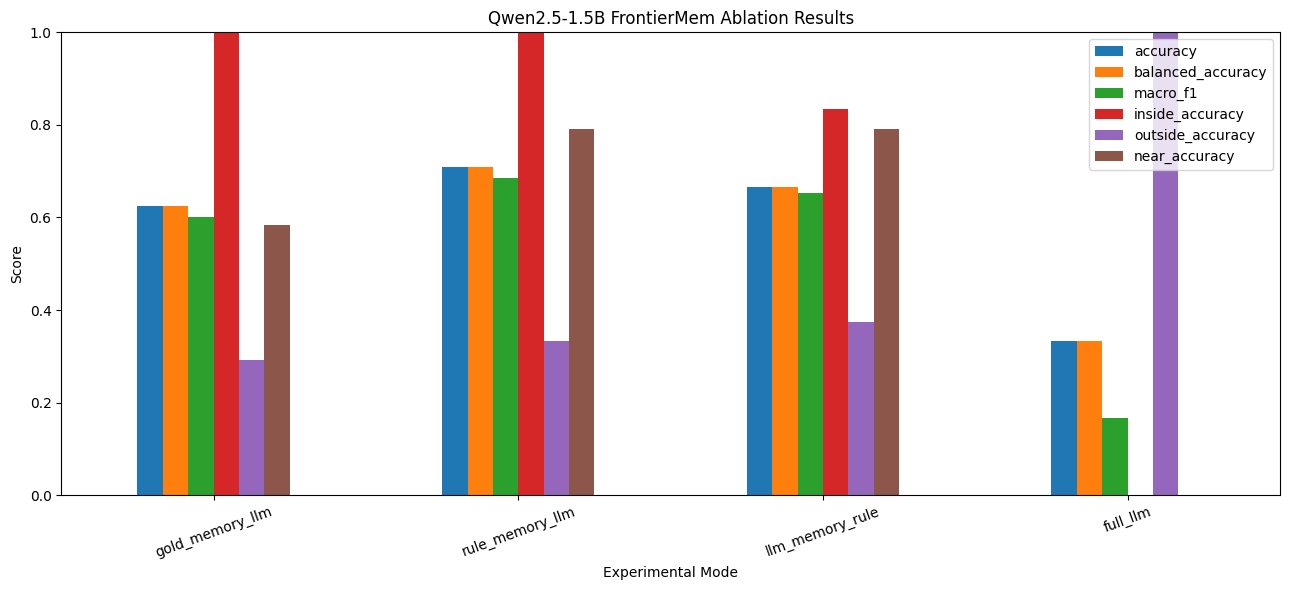

Saved: /kaggle/working/frontiermem_llm_prototype_fixed/results/qwen_1_5b_ablation_metrics.png


In [52]:
import matplotlib.pyplot as plt

plot_columns = [
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "inside_accuracy",
    "outside_accuracy",
    "near_accuracy",
]

available_plot_columns = [
    col for col in plot_columns
    if col in metrics_summary.columns
]

plot_df = (
    metrics_summary
    .set_index("mode")[
        available_plot_columns
    ]
)

ax = plot_df.plot(
    kind="bar",
    figsize=(13, 6),
)

ax.set_title(
    "Qwen2.5-1.5B FrontierMem Ablation Results"
)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_xlabel("Experimental Mode")
ax.tick_params(
    axis="x",
    rotation=20,
)

plt.tight_layout()

figure_path = (
    RESULTS_DIR
    / "qwen_1_5b_ablation_metrics.png"
)

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", figure_path)

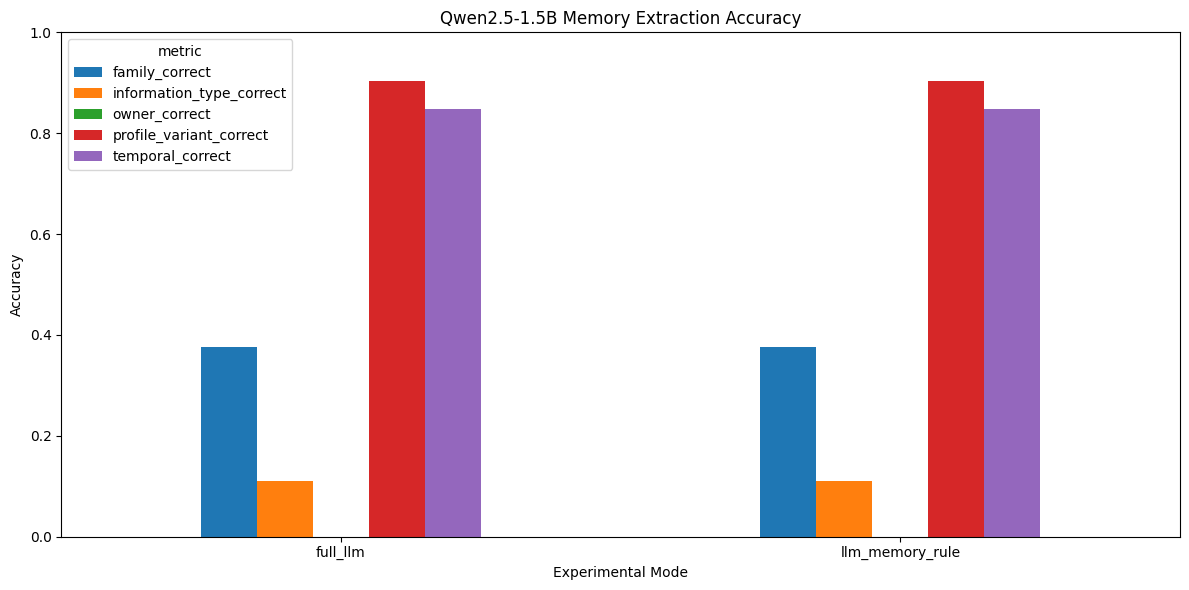

Saved: /kaggle/working/frontiermem_llm_prototype_fixed/results/qwen_1_5b_extraction_metrics.png


In [53]:
if extraction_frames:
    extraction_plot_df = (
        extraction_pivot.T
    )

    ax = extraction_plot_df.plot(
        kind="bar",
        figsize=(12, 6),
    )

    ax.set_title(
        "Qwen2.5-1.5B Memory Extraction Accuracy"
    )
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Experimental Mode")
    ax.tick_params(
        axis="x",
        rotation=0,
    )

    plt.tight_layout()

    extraction_figure_path = (
        RESULTS_DIR
        / "qwen_1_5b_extraction_metrics.png"
    )

    plt.savefig(
        extraction_figure_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

    print("Saved:", extraction_figure_path)

In [54]:
def get_metric(mode, metric):
    row = metrics_summary[
        metrics_summary["mode"] == mode
    ]

    if row.empty or metric not in row.columns:
        return float("nan")

    return float(row.iloc[0][metric])


def pct(value):
    if pd.isna(value):
        return "N/A"
    return f"{100 * value:.2f}%"


gold_accuracy = get_metric(
    "gold_memory_llm",
    "accuracy",
)

rule_memory_accuracy = get_metric(
    "rule_memory_llm",
    "accuracy",
)

llm_memory_accuracy = get_metric(
    "llm_memory_rule",
    "accuracy",
)

full_accuracy = get_metric(
    "full_llm",
    "accuracy",
)

full_macro_f1 = get_metric(
    "full_llm",
    "macro_f1",
)

full_twin = get_metric(
    "full_llm",
    "twin_exact_match",
)

if (
    not pd.isna(gold_accuracy)
    and not pd.isna(llm_memory_accuracy)
    and gold_accuracy
    > llm_memory_accuracy + 0.15
):
    bottleneck = (
        "The results suggest that memory extraction is "
        "the main bottleneck. The model performs substantially "
        "better when it receives gold structured memory."
    )
elif (
    not pd.isna(gold_accuracy)
    and gold_accuracy < 0.60
):
    bottleneck = (
        "The decision module remains a major bottleneck, "
        "because performance is limited even when gold memory "
        "is provided."
    )
else:
    bottleneck = (
        "The results suggest a mixed bottleneck: both memory "
        "construction and final applicability decisions "
        "contribute to the remaining errors."
    )

report = f"""# FrontierMem Qwen2.5-1.5B Experimental Report

## Setup

We evaluated Qwen2.5-1.5B-Instruct on 72 balanced FrontierMem
examples using four modular experimental settings:

1. Gold memory with LLM decision
2. Rule-extracted memory with LLM decision
3. LLM-extracted memory with rule-based decision
4. Full LLM memory and decision pipeline

## Main Results

| Mode | Accuracy |
|---|---:|
| Gold Memory + LLM Decision | {pct(gold_accuracy)} |
| Rule Memory + LLM Decision | {pct(rule_memory_accuracy)} |
| LLM Memory + Rule Policy | {pct(llm_memory_accuracy)} |
| Full LLM Pipeline | {pct(full_accuracy)} |

The full pipeline achieved a Macro-F1 of {pct(full_macro_f1)}
and a twin exact-match score of {pct(full_twin)}.

## Interpretation

{bottleneck}

Unlike the previous 0.5B zero-shot run, this modular evaluation
allows us to separate errors caused by memory extraction from
errors caused by the final APPLY, IGNORE, or CLARIFY decision.

## Important Caveat

The current dataset is controlled and synthetic. The rule-based
memory extractor is aligned with the scenario templates, so its
performance should not be interpreted as evidence of real-world
generalization.

## Next Step

The next research step is structured supervised fine-tuning on
counterfactual twin histories, followed by evaluation on more
natural and lexically diverse interaction histories.
"""

report_path = RESULTS_DIR / "RUN_REPORT.md"

report_path.write_text(
    report,
    encoding="utf-8",
)

print(report)
print("\nSaved:", report_path)

# FrontierMem Qwen2.5-1.5B Experimental Report

## Setup

We evaluated Qwen2.5-1.5B-Instruct on 72 balanced FrontierMem
examples using four modular experimental settings:

1. Gold memory with LLM decision
2. Rule-extracted memory with LLM decision
3. LLM-extracted memory with rule-based decision
4. Full LLM memory and decision pipeline

## Main Results

| Mode | Accuracy |
|---|---:|
| Gold Memory + LLM Decision | 62.50% |
| Rule Memory + LLM Decision | 70.83% |
| LLM Memory + Rule Policy | 66.67% |
| Full LLM Pipeline | 33.33% |

The full pipeline achieved a Macro-F1 of 16.67%
and a twin exact-match score of 0.00%.

## Interpretation

The results suggest a mixed bottleneck: both memory construction and final applicability decisions contribute to the remaining errors.

Unlike the previous 0.5B zero-shot run, this modular evaluation
allows us to separate errors caused by memory extraction from
errors caused by the final APPLY, IGNORE, or CLARIFY decision.

## Important Caveat

The curre

## 6. Export 1.5B result bundle

In [55]:
import shutil

EXPORT_DIR = Path(
    "/kaggle/working/"
    "FrontierMem_1_5B_Final_Results"
)

if EXPORT_DIR.exists():
    shutil.rmtree(EXPORT_DIR)

EXPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

patterns = [
    f"metrics_{MODEL_SLUG}_*.csv",
    f"predictions_{MODEL_SLUG}_*.csv",
    f"extraction_{MODEL_SLUG}_*.csv",
    f"confusion_{MODEL_SLUG}_*.csv",
    "qwen_1_5b_*.csv",
    "qwen_1_5b_*.png",
    "full_llm_*.csv",
    "presentation_examples.csv",
    "RUN_REPORT.md",
]

copied_files = []

for pattern in patterns:
    for source_path in RESULTS_DIR.glob(pattern):
        destination = EXPORT_DIR / source_path.name

        shutil.copy2(
            source_path,
            destination,
        )

        copied_files.append(
            destination.name
        )

# کپی اسکریپت اصلی اجرا
script_path = (
    PROJECT_DIR
    / "run_qwen_fast_ablation.py"
)

if script_path.exists():
    shutil.copy2(
        script_path,
        EXPORT_DIR
        / "run_qwen_fast_ablation.py",
    )

print("Copied files:", len(copied_files))

for name in sorted(set(copied_files)):
    print("-", name)

Copied files: 28
- RUN_REPORT.md
- confusion_Qwen2_5-1_5B-Instruct_full_llm.csv
- confusion_Qwen2_5-1_5B-Instruct_gold_memory_llm.csv
- confusion_Qwen2_5-1_5B-Instruct_llm_memory_rule.csv
- confusion_Qwen2_5-1_5B-Instruct_rule_memory_llm.csv
- extraction_Qwen2_5-1_5B-Instruct_full_llm.csv
- extraction_Qwen2_5-1_5B-Instruct_llm_memory_rule.csv
- full_llm_by_domain.csv
- full_llm_by_profile_variant.csv
- full_llm_by_query_kind.csv
- full_llm_by_zone.csv
- full_llm_correct_examples.csv
- full_llm_errors.csv
- metrics_Qwen2_5-1_5B-Instruct_full_llm.csv
- metrics_Qwen2_5-1_5B-Instruct_gold_memory_llm.csv
- metrics_Qwen2_5-1_5B-Instruct_llm_memory_rule.csv
- metrics_Qwen2_5-1_5B-Instruct_rule_memory_llm.csv
- predictions_Qwen2_5-1_5B-Instruct_full_llm.csv
- predictions_Qwen2_5-1_5B-Instruct_gold_memory_llm.csv
- predictions_Qwen2_5-1_5B-Instruct_llm_memory_rule.csv
- predictions_Qwen2_5-1_5B-Instruct_rule_memory_llm.csv
- presentation_examples.csv
- qwen_1_5b_ablation_metrics.png
- qwen_1_5b

In [56]:
archive_base = (
    "/kaggle/working/"
    "FrontierMem_1_5B_Final_Results"
)

zip_path = shutil.make_archive(
    archive_base,
    "zip",
    root_dir="/kaggle/working",
    base_dir="FrontierMem_1_5B_Final_Results",
)

print("Created:", zip_path)
print(
    "Size:",
    round(
        os.path.getsize(zip_path)
        / 1024
        / 1024,
        2,
    ),
    "MB",
)

Created: /kaggle/working/FrontierMem_1_5B_Final_Results.zip
Size: 0.23 MB


In [57]:
!ls -lh /kaggle/working/FrontierMem_1_5B_Final_Results.zip

-rw-r--r-- 1 root root 232K Aug  5 14:51 /kaggle/working/FrontierMem_1_5B_Final_Results.zip


## 7. Qwen2.5-3B gold-memory run

In [58]:
!python run_qwen_fast_ablation.py \
    --model Qwen/Qwen2.5-3B-Instruct \
    --mode gold_memory_llm \
    --max-examples 72

tokenizer_config.json: 7.30kB [00:00, 17.0MB/s]
vocab.json: 2.78MB [00:00, 43.7MB/s]
merges.txt: 1.67MB [00:00, 115MB/s]
tokenizer.json: 7.03MB [00:00, 154MB/s]
config.json: 100%|█████████████████████████████| 661/661 [00:00<00:00, 3.19MB/s]
model.safetensors.index.json: 35.6kB [00:00, 75.5MB/s]
Fetching 2 files:   0%|                                   | 0/2 [00:00<?, ?it/s]
model-00002-of-00002.safetensors:   0%|             | 0.00/2.20G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|             | 0.00/3.97G [00:00<?, ?B/s]
model-00002-of-00002.safetensors:   0%|             | 0.00/2.20G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|             | 0.00/3.97G [00:00<?, ?B/s]
model-00002-of-00002.safetensors:   0%|             | 0.00/2.20G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|  | 20.3k/3.97G [00:00<10:52:41, 101kB/s]
model-00002-of-00002.safetensors:   0%|             | 0.00/2.20G [00:00<?, ?B/s]
model-00002-of-00002.safetensors:   0%|             

## 8. Cross-model comparison (1.5B vs 3B + local baselines)

In [59]:
from pathlib import Path
import os
import re
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_DIR = Path(
    "/kaggle/working/frontiermem_llm_prototype_fixed"
)

RESULTS_DIR = PROJECT_DIR / "results"

OUTPUT_DIR = Path(
    "/kaggle/working/FrontierMem_All_Model_Comparison"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MODES = [
    "gold_memory_llm",
    "rule_memory_llm",
    "llm_memory_rule",
    "full_llm",
]

LABELS = [
    "APPLY",
    "IGNORE",
    "CLARIFY",
]

MODEL_NAME_MAP = {
    "Qwen2_5-0_5B-Instruct": "Qwen2.5-0.5B-Instruct",
    "Qwen2_5-1_5B-Instruct": "Qwen2.5-1.5B-Instruct",
    "Qwen2_5-3B-Instruct": "Qwen2.5-3B-Instruct",
}

print("Results directory:", RESULTS_DIR)
print("Exists:", RESULTS_DIR.exists())

print("\nAvailable result files:")

for path in sorted(RESULTS_DIR.glob("*")):
    if path.is_file():
        print(
            path.name,
            "-",
            round(path.stat().st_size / 1024, 2),
            "KB",
        )

Results directory: /kaggle/working/frontiermem_llm_prototype_fixed/results
Exists: True

Available result files:
RUN_REPORT.md - 1.36 KB
boundary_metrics_all_local.png - 114.86 KB
boundary_metrics_rules.png - 87.7 KB
boundary_metrics_tiny_lm.png - 76.41 KB
confusion_Qwen2_5-1_5B-Instruct_full_llm.csv - 0.07 KB
confusion_Qwen2_5-1_5B-Instruct_gold_memory_llm.csv - 0.07 KB
confusion_Qwen2_5-1_5B-Instruct_llm_memory_rule.csv - 0.07 KB
confusion_Qwen2_5-1_5B-Instruct_rule_memory_llm.csv - 0.07 KB
error_rates_all_local.png - 115.29 KB
error_rates_rules.png - 88.49 KB
error_rates_tiny_lm.png - 79.68 KB
example_rule_memories.json - 54.33 KB
extraction_Qwen2_5-1_5B-Instruct_full_llm.csv - 0.17 KB
extraction_Qwen2_5-1_5B-Instruct_llm_memory_rule.csv - 0.17 KB
full_llm_by_domain.csv - 0.15 KB
full_llm_by_profile_variant.csv - 0.08 KB
full_llm_by_query_kind.csv - 0.09 KB
full_llm_by_zone.csv - 0.07 KB
full_llm_correct_examples.csv - 9.67 KB
full_llm_errors.csv - 50.94 KB
main_metrics_all_local.pn

In [60]:
def pretty_model_name(model_slug):
    return MODEL_NAME_MAP.get(
        model_slug,
        model_slug.replace("_", "."),
    )


def parse_model_and_mode(filename, prefix):
    mode_pattern = "|".join(
        re.escape(mode)
        for mode in MODES
    )

    pattern = (
        rf"^{re.escape(prefix)}_"
        rf"(.+)_({mode_pattern})\.csv$"
    )

    match = re.match(pattern, filename)

    if match is None:
        return None

    return match.group(1), match.group(2)


def normalize_metric_file(path):
    df = pd.read_csv(path)

    # حالت long format: metric, score
    if {"metric", "score"}.issubset(df.columns):
        normalized = (
            df[["metric", "score"]]
            .dropna(subset=["metric"])
            .drop_duplicates("metric")
            .set_index("metric")["score"]
            .to_frame()
            .T
            .reset_index(drop=True)
        )

        return normalized

    # حالت wide format
    if len(df) == 0:
        return pd.DataFrame()

    return df.iloc[[0]].copy()


metric_frames = []

# فرمت جدید برای مدل‌های 1.5B و 3B
for path in sorted(RESULTS_DIR.glob("metrics_*.csv")):
    parsed = parse_model_and_mode(
        path.name,
        "metrics",
    )

    if parsed is None:
        continue

    model_slug, mode = parsed
    part = normalize_metric_file(path)

    if part.empty:
        continue

    part["model"] = pretty_model_name(model_slug)
    part["model_slug"] = model_slug
    part["mode"] = mode
    part["source_file"] = path.name

    metric_frames.append(part)


# نتیجه قدیمی Qwen 0.5B
legacy_metric_path = (
    RESULTS_DIR / "metrics_qwen_small.csv"
)

if legacy_metric_path.exists():
    part = normalize_metric_file(
        legacy_metric_path
    )

    if not part.empty:
        part["model"] = "Qwen2.5-0.5B-Instruct"
        part["model_slug"] = "Qwen2_5-0_5B-Instruct"
        part["mode"] = "legacy_full_llm"
        part["source_file"] = legacy_metric_path.name

        metric_frames.append(part)


# Baselineهای محلی اولیه
local_metrics_path = (
    RESULTS_DIR / "metrics_all_local.csv"
)

if local_metrics_path.exists():
    local_df = pd.read_csv(local_metrics_path)

    if "model" in local_df.columns:
        local_df = local_df.copy()
        local_df["model_slug"] = (
            local_df["model"]
            .astype(str)
            .str.replace(" ", "_", regex=False)
        )
        local_df["mode"] = "local_baseline"
        local_df["source_file"] = local_metrics_path.name

        metric_frames.append(local_df)


assert metric_frames, (
    "No metric files were found in the results directory."
)

all_metrics = pd.concat(
    metric_frames,
    ignore_index=True,
    sort=False,
)

metadata_columns = [
    "model",
    "mode",
    "model_slug",
    "source_file",
]

metric_columns = [
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "inside_accuracy",
    "outside_accuracy",
    "near_accuracy",
    "overgeneralization_rate",
    "unnecessary_clarification_rate",
    "twin_exact_match",
    "twin_discrimination_accuracy",
    "n_examples",
]

available_metric_columns = [
    col for col in metric_columns
    if col in all_metrics.columns
]

comparison_table = all_metrics[
    metadata_columns[:2]
    + available_metric_columns
].copy()

comparison_table = comparison_table.sort_values(
    ["model", "mode"]
).reset_index(drop=True)

print("Combined results:")
display(comparison_table)

Combined results:


,model,mode,accuracy,balanced_accuracy,macro_f1,inside_accuracy,outside_accuracy,near_accuracy,overgeneralization_rate,unnecessary_clarification_rate,twin_exact_match,twin_discrimination_accuracy,n_examples
0,Flat Fact Memory,local_baseline,0.666667,0.333333,0.266667,1.000000,0.000000,0.000000,1.000000,0.000000,0.333333,0.000000,1152
1,FrontierMem-Lite (Rules),local_baseline,0.971354,0.957031,0.954784,0.985677,0.942708,0.942708,0.000000,0.019792,0.942708,0.981771,1152
2,Query-Only TF-IDF,local_baseline,0.635417,0.527344,0.510117,0.743490,0.177083,0.661458,0.822917,0.132292,0.302083,0.000000,1152
3,Qwen2.5-1.5B-Instruct,full_llm,0.333333,0.333333,0.166667,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,72
4,Qwen2.5-1.5B-Instruct,gold_memory_llm,0.625000,0.625000,0.600402,1.000000,0.291667,0.583333,0.583333,0.062500,0.666667,0.666667,72
5,Qwen2.5-1.5B-Instruct,llm_memory_rule,0.666667,0.666667,0.653465,0.833333,0.375000,0.791667,0.125000,0.333333,0.333333,0.666667,72
6,Qwen2.5-1.5B-Instruct,rule_memory_llm,0.708333,0.708333,0.684453,1.000000,0.333333,0.791667,0.541667,0.062500,1.000000,1.000000,72
7,Qwen2.5-3B-Instruct,gold_memory_llm,0.750000,0.750000,0.735502,0.458333,0.791667,1.000000,0.041667,0.270833,0.000000,0.000000,72
8,Raw Long-Context TF-IDF,local_baseline,0.795139,0.840278,0.780215,0.750000,0.979167,0.791667,0.000000,0.007292,0.590278,1.000000,1152
9,Tiny Transformer LM (end-to-end heads),local_baseline,0.664931,0.344184,0.295730,0.985677,0.031250,0.015625,0.963542,0.004167,0.333333,0.057292,1152


In [61]:
percentage_table = comparison_table.copy()

percentage_columns = [
    col
    for col in percentage_table.columns
    if col not in [
        "model",
        "mode",
        "n_examples",
    ]
]

for col in percentage_columns:
    percentage_table[col] = pd.to_numeric(
        percentage_table[col],
        errors="coerce",
    )

    percentage_table[col] = (
        percentage_table[col] * 100
    ).round(2)

display(
    percentage_table.sort_values(
        "accuracy",
        ascending=False,
    ).reset_index(drop=True)
)

comparison_table.to_csv(
    OUTPUT_DIR / "all_model_metrics_raw.csv",
    index=False,
)

percentage_table.to_csv(
    OUTPUT_DIR / "all_model_metrics_percent.csv",
    index=False,
)

,model,mode,accuracy,balanced_accuracy,macro_f1,inside_accuracy,outside_accuracy,near_accuracy,overgeneralization_rate,unnecessary_clarification_rate,twin_exact_match,twin_discrimination_accuracy,n_examples
0,FrontierMem-Lite (Rules),local_baseline,97.14,95.70,95.48,98.57,94.27,94.27,0.00,1.98,94.27,98.18,1152
1,Tiny Transformer Memory + Rule Policy,local_baseline,93.66,89.80,90.93,97.53,85.94,85.94,8.33,2.40,88.02,89.58,1152
2,Raw Long-Context TF-IDF,local_baseline,79.51,84.03,78.02,75.00,97.92,79.17,0.00,0.73,59.03,100.00,1152
3,Qwen2.5-3B-Instruct,gold_memory_llm,75.00,75.00,73.55,45.83,79.17,100.00,4.17,27.08,0.00,0.00,72
4,Qwen2.5-1.5B-Instruct,rule_memory_llm,70.83,70.83,68.45,100.00,33.33,79.17,54.17,6.25,100.00,100.00,72
5,Qwen2.5-1.5B-Instruct,llm_memory_rule,66.67,66.67,65.35,83.33,37.50,79.17,12.50,33.33,33.33,66.67,72
6,Flat Fact Memory,local_baseline,66.67,33.33,26.67,100.00,0.00,0.00,100.00,0.00,33.33,0.00,1152
7,Tiny Transformer LM (end-to-end heads),local_baseline,66.49,34.42,29.57,98.57,3.12,1.56,96.35,0.42,33.33,5.73,1152
8,Query-Only TF-IDF,local_baseline,63.54,52.73,51.01,74.35,17.71,66.15,82.29,13.23,30.21,0.00,1152
9,Qwen2.5-1.5B-Instruct,gold_memory_llm,62.50,62.50,60.04,100.00,29.17,58.33,58.33,6.25,66.67,66.67,72


In [62]:
TARGET_MODELS = [
    "Qwen2.5-1.5B-Instruct",
    "Qwen2.5-3B-Instruct",
]

target_df = comparison_table[
    comparison_table["model"].isin(
        TARGET_MODELS
    )
].copy()

delta_metrics = [
    metric
    for metric in [
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
        "inside_accuracy",
        "outside_accuracy",
        "near_accuracy",
        "twin_exact_match",
        "twin_discrimination_accuracy",
    ]
    if metric in target_df.columns
]

delta_rows = []

for mode in MODES:
    mode_df = target_df[
        target_df["mode"] == mode
    ]

    available_models = set(
        mode_df["model"].tolist()
    )

    if not set(TARGET_MODELS).issubset(
        available_models
    ):
        continue

    row_15 = mode_df[
        mode_df["model"]
        == "Qwen2.5-1.5B-Instruct"
    ].iloc[0]

    row_3 = mode_df[
        mode_df["model"]
        == "Qwen2.5-3B-Instruct"
    ].iloc[0]

    result = {
        "mode": mode,
    }

    for metric in delta_metrics:
        score_15 = pd.to_numeric(
            row_15.get(metric),
            errors="coerce",
        )

        score_3 = pd.to_numeric(
            row_3.get(metric),
            errors="coerce",
        )

        result[f"1.5B_{metric}"] = score_15
        result[f"3B_{metric}"] = score_3

        # اختلاف بر حسب percentage point
        result[f"delta_pp_{metric}"] = (
            (score_3 - score_15) * 100
        )

    delta_rows.append(result)

delta_df = pd.DataFrame(delta_rows)

if delta_df.empty:
    print(
        "No common completed modes were found "
        "between 1.5B and 3B."
    )
else:
    display(delta_df.round(4))

    delta_df.to_csv(
        OUTPUT_DIR
        / "qwen_3b_vs_1_5b_deltas.csv",
        index=False,
    )

,mode,1.5B_accuracy,3B_accuracy,delta_pp_accuracy,1.5B_balanced_accuracy,3B_balanced_accuracy,delta_pp_balanced_accuracy,1.5B_macro_f1,3B_macro_f1,delta_pp_macro_f1,...,delta_pp_outside_accuracy,1.5B_near_accuracy,3B_near_accuracy,delta_pp_near_accuracy,1.5B_twin_exact_match,3B_twin_exact_match,delta_pp_twin_exact_match,1.5B_twin_discrimination_accuracy,3B_twin_discrimination_accuracy,delta_pp_twin_discrimination_accuracy
0,gold_memory_llm,0.625,0.75,12.5,0.625,0.75,12.5,0.6004,0.7355,13.51,...,50.0,0.5833,1.0,41.6667,0.6667,0.0,-66.6667,0.6667,0.0,-66.6667


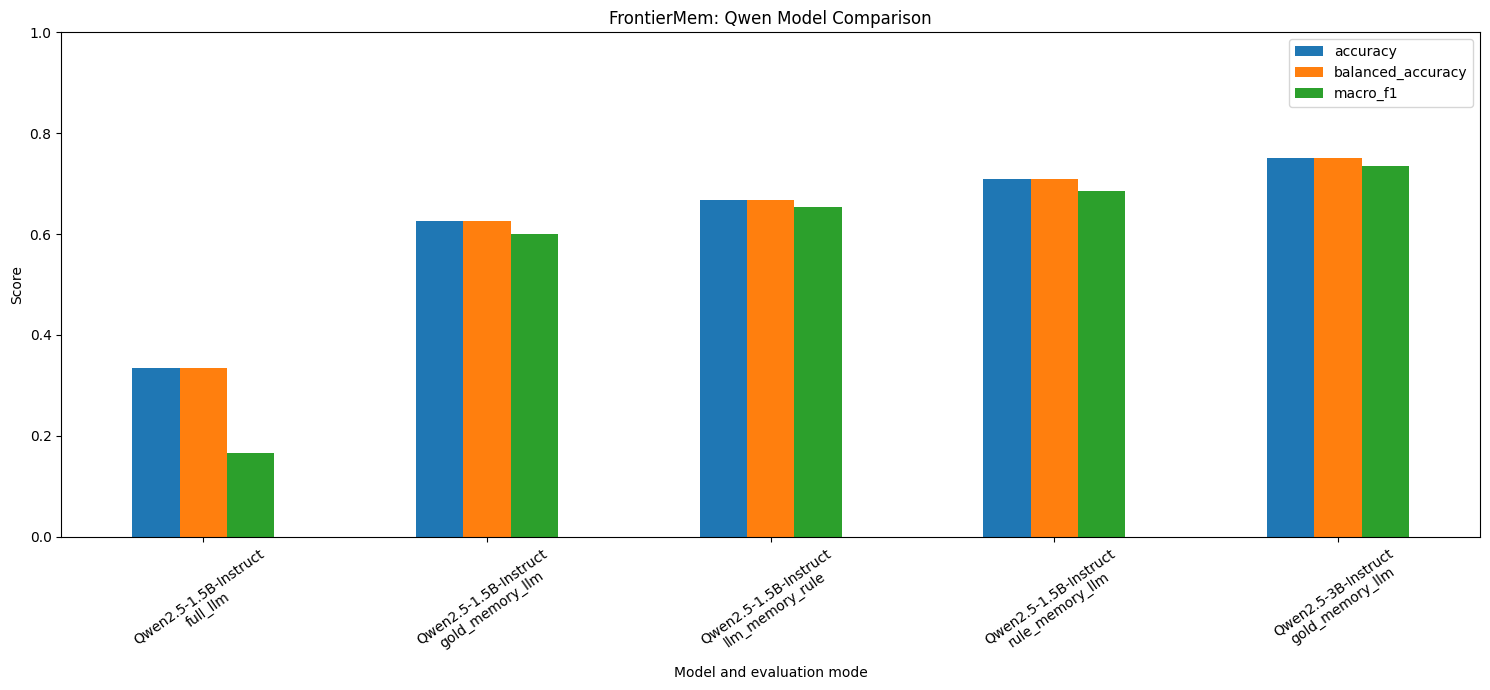

Saved: /kaggle/working/FrontierMem_All_Model_Comparison/qwen_all_models_main_metrics.png


In [63]:
qwen_comparison = comparison_table[
    comparison_table["model"].str.contains(
        "Qwen",
        case=False,
        na=False,
    )
].copy()

qwen_comparison["run"] = (
    qwen_comparison["model"]
    + "\n"
    + qwen_comparison["mode"]
)

main_plot_metrics = [
    col
    for col in [
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
    ]
    if col in qwen_comparison.columns
]

main_plot_df = (
    qwen_comparison
    .set_index("run")[
        main_plot_metrics
    ]
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
)

ax = main_plot_df.plot(
    kind="bar",
    figsize=(15, 7),
)

ax.set_title(
    "FrontierMem: Qwen Model Comparison"
)
ax.set_xlabel("Model and evaluation mode")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.tick_params(
    axis="x",
    rotation=35,
)

plt.tight_layout()

main_plot_path = (
    OUTPUT_DIR
    / "qwen_all_models_main_metrics.png"
)

plt.savefig(
    main_plot_path,
    dpi=220,
    bbox_inches="tight",
)

plt.show()

print("Saved:", main_plot_path)

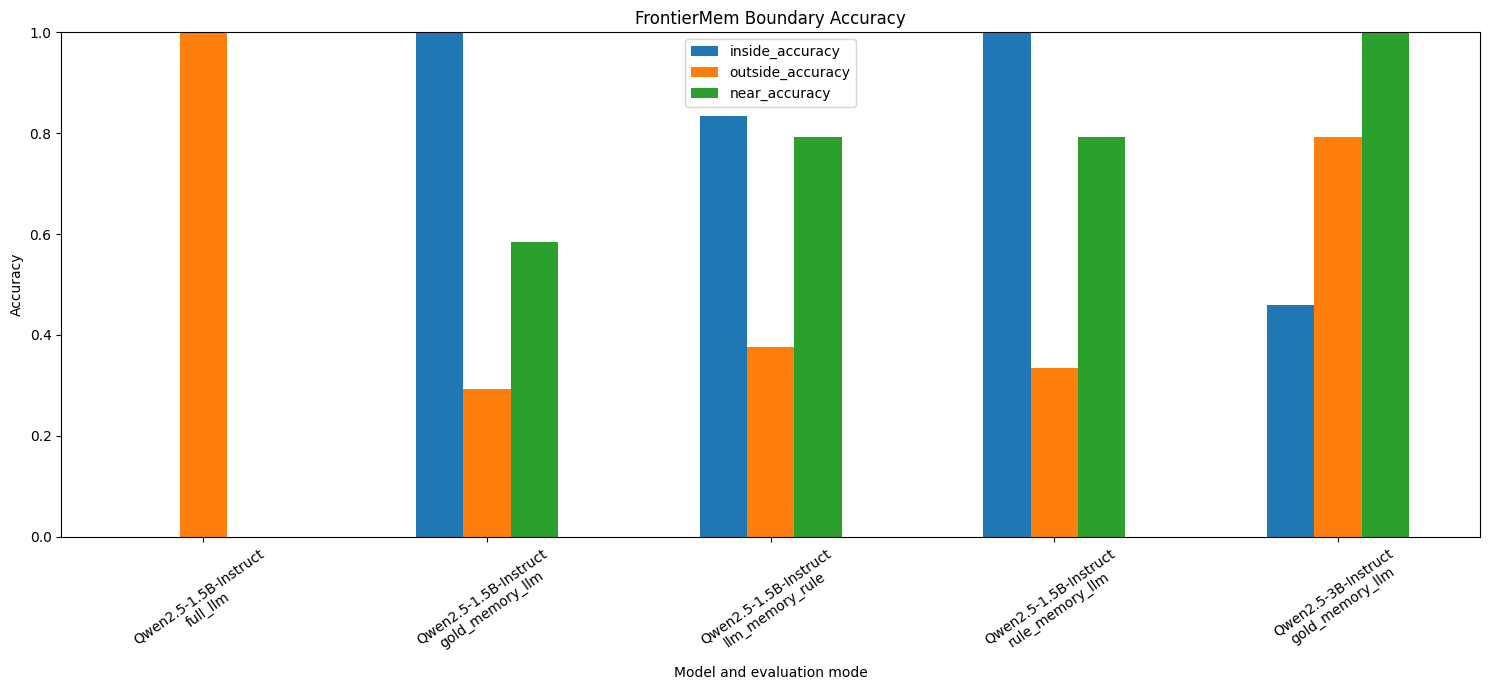

Saved: /kaggle/working/FrontierMem_All_Model_Comparison/qwen_all_models_boundary_metrics.png


In [64]:
boundary_metrics = [
    col
    for col in [
        "inside_accuracy",
        "outside_accuracy",
        "near_accuracy",
    ]
    if col in qwen_comparison.columns
]

if boundary_metrics:
    boundary_plot_df = (
        qwen_comparison
        .set_index("run")[
            boundary_metrics
        ]
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
    )

    ax = boundary_plot_df.plot(
        kind="bar",
        figsize=(15, 7),
    )

    ax.set_title(
        "FrontierMem Boundary Accuracy"
    )
    ax.set_xlabel("Model and evaluation mode")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1)
    ax.tick_params(
        axis="x",
        rotation=35,
    )

    plt.tight_layout()

    boundary_plot_path = (
        OUTPUT_DIR
        / "qwen_all_models_boundary_metrics.png"
    )

    plt.savefig(
        boundary_plot_path,
        dpi=220,
        bbox_inches="tight",
    )

    plt.show()

    print("Saved:", boundary_plot_path)

## 9. Robust prediction-distribution and collapse analysis

In [70]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

RESULTS_DIR = Path(
    "/kaggle/working/frontiermem_llm_prototype_fixed/results"
)

OUTPUT_DIR = Path(
    "/kaggle/working/FrontierMem_All_Model_Comparison"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MODES = [
    "gold_memory_llm",
    "rule_memory_llm",
    "llm_memory_rule",
    "full_llm",
]

LABELS = [
    "APPLY",
    "IGNORE",
    "CLARIFY",
]

MODEL_NAME_MAP = {
    "Qwen2_5-0_5B-Instruct": "Qwen2.5-0.5B-Instruct",
    "Qwen2_5-1_5B-Instruct": "Qwen2.5-1.5B-Instruct",
    "Qwen2_5-3B-Instruct": "Qwen2.5-3B-Instruct",
}


def pretty_model_name(model_slug):
    return MODEL_NAME_MAP.get(
        model_slug,
        model_slug.replace("_", "."),
    )


def parse_prediction_filename(filename):
    mode_pattern = "|".join(
        re.escape(mode)
        for mode in MODES
    )

    pattern = (
        rf"^predictions_(.+)_"
        rf"({mode_pattern})\.csv$"
    )

    match = re.match(pattern, filename)

    if match is None:
        return None

    return match.group(1), match.group(2)


prediction_runs = []


# خواندن خروجی‌های جدید 1.5B و 3B
for path in sorted(
    RESULTS_DIR.glob("predictions_*.csv")
):
    parsed = parse_prediction_filename(
        path.name
    )

    if parsed is None:
        continue

    model_slug, mode = parsed
    df = pd.read_csv(path)

    # پشتیبانی از نام‌های مختلف ستون
    if "action" in df.columns:
        gold_column = "action"
    elif "gold_action" in df.columns:
        gold_column = "gold_action"
    else:
        print(
            "Skipped because gold column is missing:",
            path.name,
        )
        continue

    if "prediction" in df.columns:
        prediction_column = "prediction"
    elif "pred_action" in df.columns:
        prediction_column = "pred_action"
    elif "predicted_action" in df.columns:
        prediction_column = "predicted_action"
    else:
        print(
            "Skipped because prediction column is missing:",
            path.name,
        )
        continue

    work = df.copy()

    work["action"] = (
        work[gold_column]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    work["prediction"] = (
        work[prediction_column]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    work["model"] = pretty_model_name(
        model_slug
    )

    work["model_slug"] = model_slug
    work["mode"] = mode
    work["source_file"] = path.name

    prediction_runs.append(work)


# خواندن نتیجه قدیمی 0.5B
legacy_path = (
    RESULTS_DIR
    / "test_predictions_qwen_small.csv"
)

if legacy_path.exists():
    df = pd.read_csv(legacy_path)

    if {
        "action",
        "prediction",
    }.issubset(df.columns):
        work = df.copy()

        work["action"] = (
            work["action"]
            .astype(str)
            .str.strip()
            .str.upper()
        )

        work["prediction"] = (
            work["prediction"]
            .astype(str)
            .str.strip()
            .str.upper()
        )

        work["model"] = (
            "Qwen2.5-0.5B-Instruct"
        )

        work["model_slug"] = (
            "Qwen2_5-0_5B-Instruct"
        )

        work["mode"] = "legacy_full_llm"
        work["source_file"] = legacy_path.name

        prediction_runs.append(work)


print(
    "Number of prediction runs found:",
    len(prediction_runs),
)

for df in prediction_runs:
    print(
        df["model"].iloc[0],
        "|",
        df["mode"].iloc[0],
        "|",
        len(df),
        "examples",
    )

assert prediction_runs, (
    "No valid prediction CSV files were found."
)

Number of prediction runs found: 5
Qwen2.5-1.5B-Instruct | full_llm | 72 examples
Qwen2.5-1.5B-Instruct | gold_memory_llm | 72 examples
Qwen2.5-1.5B-Instruct | llm_memory_rule | 72 examples
Qwen2.5-1.5B-Instruct | rule_memory_llm | 72 examples
Qwen2.5-3B-Instruct | gold_memory_llm | 72 examples


In [71]:
distribution_rows = []
collapse_rows = []

for df in prediction_runs:
    model = df["model"].iloc[0]
    mode = df["mode"].iloc[0]
    total = len(df)

    gold_counts = (
        df["action"]
        .value_counts()
    )

    prediction_counts = (
        df["prediction"]
        .value_counts()
    )

    dominant_prediction = (
        prediction_counts.idxmax()
        if not prediction_counts.empty
        else "NONE"
    )

    dominant_count = (
        int(prediction_counts.max())
        if not prediction_counts.empty
        else 0
    )

    dominant_share = (
        dominant_count / total
        if total > 0
        else np.nan
    )

    collapse_rows.append({
        "model": model,
        "mode": mode,
        "n_examples": total,
        "dominant_prediction":
            dominant_prediction,
        "dominant_prediction_count":
            dominant_count,
        "dominant_prediction_share":
            dominant_share,
        "possible_collapse":
            dominant_share >= 0.90,
    })

    for label in LABELS:
        gold_count = int(
            gold_counts.get(label, 0)
        )

        prediction_count = int(
            prediction_counts.get(label, 0)
        )

        distribution_rows.append({
            "model": model,
            "mode": mode,
            "label": label,
            "gold_count": gold_count,
            "prediction_count":
                prediction_count,
            "prediction_share": (
                prediction_count / total
                if total > 0
                else np.nan
            ),
        })


distribution_df = pd.DataFrame(
    distribution_rows
)

collapse_df = pd.DataFrame(
    collapse_rows
)

print("Columns in distribution_df:")
print(distribution_df.columns.tolist())

print("\nPrediction distributions:")
display(distribution_df)

print("\nCollapse analysis:")
display(
    collapse_df.sort_values(
        "dominant_prediction_share",
        ascending=False,
    ).reset_index(drop=True)
)

distribution_df.to_csv(
    OUTPUT_DIR
    / "all_prediction_distributions.csv",
    index=False,
)

collapse_df.to_csv(
    OUTPUT_DIR
    / "all_collapse_analysis.csv",
    index=False,
)

Columns in distribution_df:
['model', 'mode', 'label', 'gold_count', 'prediction_count', 'prediction_share']

Prediction distributions:


,model,mode,label,gold_count,prediction_count,prediction_share
0,Qwen2.5-1.5B-Instruct,full_llm,APPLY,24,0,0.000000
1,Qwen2.5-1.5B-Instruct,full_llm,IGNORE,24,72,1.000000
2,Qwen2.5-1.5B-Instruct,full_llm,CLARIFY,24,0,0.000000
3,Qwen2.5-1.5B-Instruct,gold_memory_llm,APPLY,24,48,0.666667
4,Qwen2.5-1.5B-Instruct,gold_memory_llm,IGNORE,24,7,0.097222
5,Qwen2.5-1.5B-Instruct,gold_memory_llm,CLARIFY,24,17,0.236111
6,Qwen2.5-1.5B-Instruct,llm_memory_rule,APPLY,24,25,0.347222
7,Qwen2.5-1.5B-Instruct,llm_memory_rule,IGNORE,24,12,0.166667
8,Qwen2.5-1.5B-Instruct,llm_memory_rule,CLARIFY,24,35,0.486111
9,Qwen2.5-1.5B-Instruct,rule_memory_llm,APPLY,24,42,0.583333



Collapse analysis:


,model,mode,n_examples,dominant_prediction,dominant_prediction_count,dominant_prediction_share,possible_collapse
0,Qwen2.5-1.5B-Instruct,full_llm,72,IGNORE,72,1.000000,True
1,Qwen2.5-1.5B-Instruct,gold_memory_llm,72,APPLY,48,0.666667,False
2,Qwen2.5-1.5B-Instruct,rule_memory_llm,72,APPLY,42,0.583333,False
3,Qwen2.5-3B-Instruct,gold_memory_llm,72,CLARIFY,37,0.513889,False
4,Qwen2.5-1.5B-Instruct,llm_memory_rule,72,CLARIFY,35,0.486111,False


label                                     APPLY    IGNORE   CLARIFY
model                 mode                                         
Qwen2.5-1.5B-Instruct full_llm         0.000000  1.000000  0.000000
                      gold_memory_llm  0.666667  0.097222  0.236111
                      llm_memory_rule  0.347222  0.166667  0.486111
                      rule_memory_llm  0.583333  0.111111  0.305556
Qwen2.5-3B-Instruct   gold_memory_llm  0.166667  0.319444  0.513889

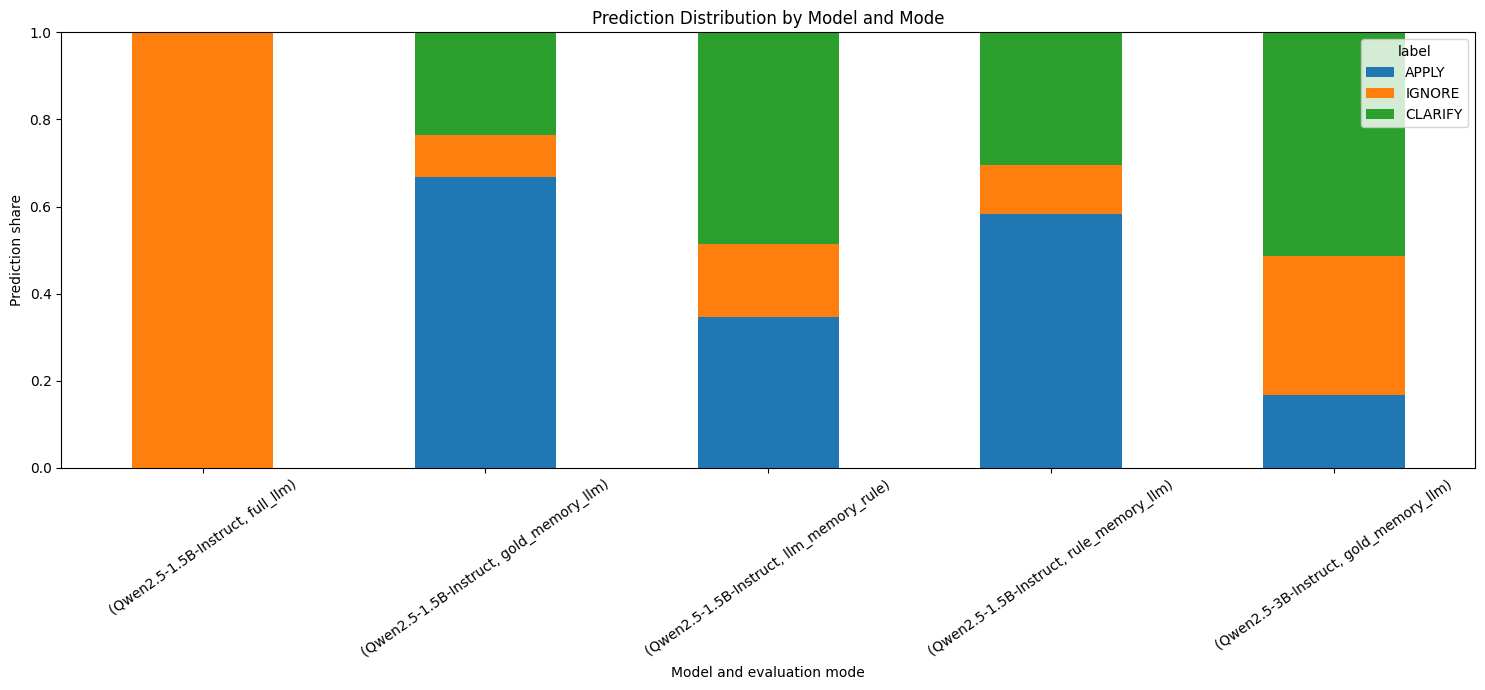

Saved: /kaggle/working/FrontierMem_All_Model_Comparison/all_prediction_distributions.png


In [72]:
prediction_distribution_plot = (
    distribution_df
    .pivot_table(
        index=["model", "mode"],
        columns="label",
        values="prediction_share",
        aggfunc="sum",
        fill_value=0,
    )
    .reindex(
        columns=LABELS,
        fill_value=0,
    )
)

display(prediction_distribution_plot)

ax = prediction_distribution_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(15, 7),
)

ax.set_title(
    "Prediction Distribution by Model and Mode"
)

ax.set_xlabel(
    "Model and evaluation mode"
)

ax.set_ylabel(
    "Prediction share"
)

ax.set_ylim(0, 1)

ax.tick_params(
    axis="x",
    rotation=35,
)

plt.tight_layout()

distribution_plot_path = (
    OUTPUT_DIR
    / "all_prediction_distributions.png"
)

plt.savefig(
    distribution_plot_path,
    dpi=220,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    distribution_plot_path,
)

In [73]:
collapse_view = collapse_df.copy()

collapse_view[
    "dominant_prediction_share"
] = (
    collapse_view[
        "dominant_prediction_share"
    ]
    * 100
).round(2)

display(
    collapse_view[
        [
            "model",
            "mode",
            "n_examples",
            "dominant_prediction",
            "dominant_prediction_count",
            "dominant_prediction_share",
            "possible_collapse",
        ]
    ]
    .sort_values(
        "dominant_prediction_share",
        ascending=False,
    )
    .reset_index(drop=True)
)

,model,mode,n_examples,dominant_prediction,dominant_prediction_count,dominant_prediction_share,possible_collapse
0,Qwen2.5-1.5B-Instruct,full_llm,72,IGNORE,72,100.00,True
1,Qwen2.5-1.5B-Instruct,gold_memory_llm,72,APPLY,48,66.67,False
2,Qwen2.5-1.5B-Instruct,rule_memory_llm,72,APPLY,42,58.33,False
3,Qwen2.5-3B-Instruct,gold_memory_llm,72,CLARIFY,37,51.39,False
4,Qwen2.5-1.5B-Instruct,llm_memory_rule,72,CLARIFY,35,48.61,False


## 10. Export cross-model comparison artifacts

In [ ]:
from pathlib import Path
import shutil

OUTPUT_DIR = Path('/kaggle/working/FrontierMem_All_Model_Comparison')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save the key aggregate tables when they exist in memory.
if 'comparison_table' in globals():
    comparison_table.to_csv(OUTPUT_DIR / 'all_model_metrics_raw.csv', index=False)
if 'percentage_table' in globals():
    percentage_table.to_csv(OUTPUT_DIR / 'all_model_metrics_percent.csv', index=False)
if 'delta_df' in globals() and not delta_df.empty:
    delta_df.to_csv(OUTPUT_DIR / 'qwen_3b_vs_1_5b_deltas.csv', index=False)
if 'distribution_df' in globals():
    distribution_df.to_csv(OUTPUT_DIR / 'all_prediction_distributions.csv', index=False)
if 'collapse_df' in globals():
    collapse_df.to_csv(OUTPUT_DIR / 'all_collapse_analysis.csv', index=False)

zip_path = shutil.make_archive(
    '/kaggle/working/FrontierMem_All_Model_Comparison',
    'zip',
    root_dir='/kaggle/working',
    base_dir='FrontierMem_All_Model_Comparison',
)
print('Saved:', zip_path)